# Adressing overfitting using pruning in decision tree

When learning decision tree, one of the main risk that can occur is overfitting. Basically the problem is that our model fit very well the training data but may fail to generalize on new unseen example. One solution to adress the problem of overfitting is pruning.

## What is pruning?
Pruning is the process of reducing the size of a decision tree, removing some branches and nodes that contribute little to predicting the target variable.
There exists different types of pruning like for example pre-pruning or post-pruning approaches.


In this notebook we will see an example of how pruning can lead to better performace using the Titanic dataset, on which we will perform a binary classification task regarding the survival of a passenger on the Titanic. Note that I set the ```random_state``` parameter to make the results reproducible.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix

# Loading the dataset and visualize its content

https://www.kaggle.com/datasets/yasserh/titanic-dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


To be able to to run the notebook, upload the "Titanic-Dataset.csv" file containing the dataset in the content folder inside the colab enviroment.

The Titanic dataset has 11 features and 1 target for a total of 12 columns.

In [4]:
df = pd.read_csv('/kaggle/input/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data cleaning and features preparation
When we have a look at the Titanic dataset we can see that some of the columns contain unique values such as "Name" and "Ticket". We can simply drop this columns because they are not relevant to predict target values. We also have other features that contains strings such as "Sex" or "Cabin", therefore an encoding is needed to handle them. Finally, we must deal with some missing values for the "Embarked" and "Age" attributes. I will use a standard approach therefore replacing the missing value with the most frequent values for the attribute considering all the examples in the training set for the "Embarked" attribute, while for the "Age" I will determine the missing value based on related feature like "Sex" and "Pclass".

In [5]:
df['Sex'] = (df['Sex'] == 'male').astype(int) # 1 for male and 0 for female

df['Deck'] = df['Cabin'].astype(str).str[0] # take the first letter of the Cabin value

# Replace missing with 'Unknown'
df['Deck'] = df['Deck'].replace('n', 'Unknown')

# Map letters to numbers
deck_map = {letter: i for i, letter in enumerate(sorted(df['Deck'].unique()))}
df['Deck_num'] = df['Deck'].map(deck_map)

# Replace the missing value with take the most frequent values for Embarked
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)
df['Embarked_code'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Here we are replacing missing values for ages considering the median for each (sex, pclass) group
# For this particular step I was helped by LLM
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# There could be other NaN values in the case when for a particular group (sex, pclass) all the values are equal to NaN
# Therefore we replace with the global median in this case
df.fillna({'Age': df['Age'].median}, inplace=True)

In [6]:
# We can drop all the columns that are irrelevant at this point
X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin', 'Deck', 'Embarked'], axis=1)
y = df['Survived'] # target values
print(X.shape)
print(y.shape)

(891, 8)
(891,)


# Training

Before training we split the whole training set in a train set and a test set. To make the results reproducible we use a random state.

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=2)
# stratify allow to mantain the same proportion between target values on both train set and test set
print(X_train.shape)
print(X_test.shape)

(668, 8)
(223, 8)


In [8]:
model = tree.DecisionTreeClassifier(random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

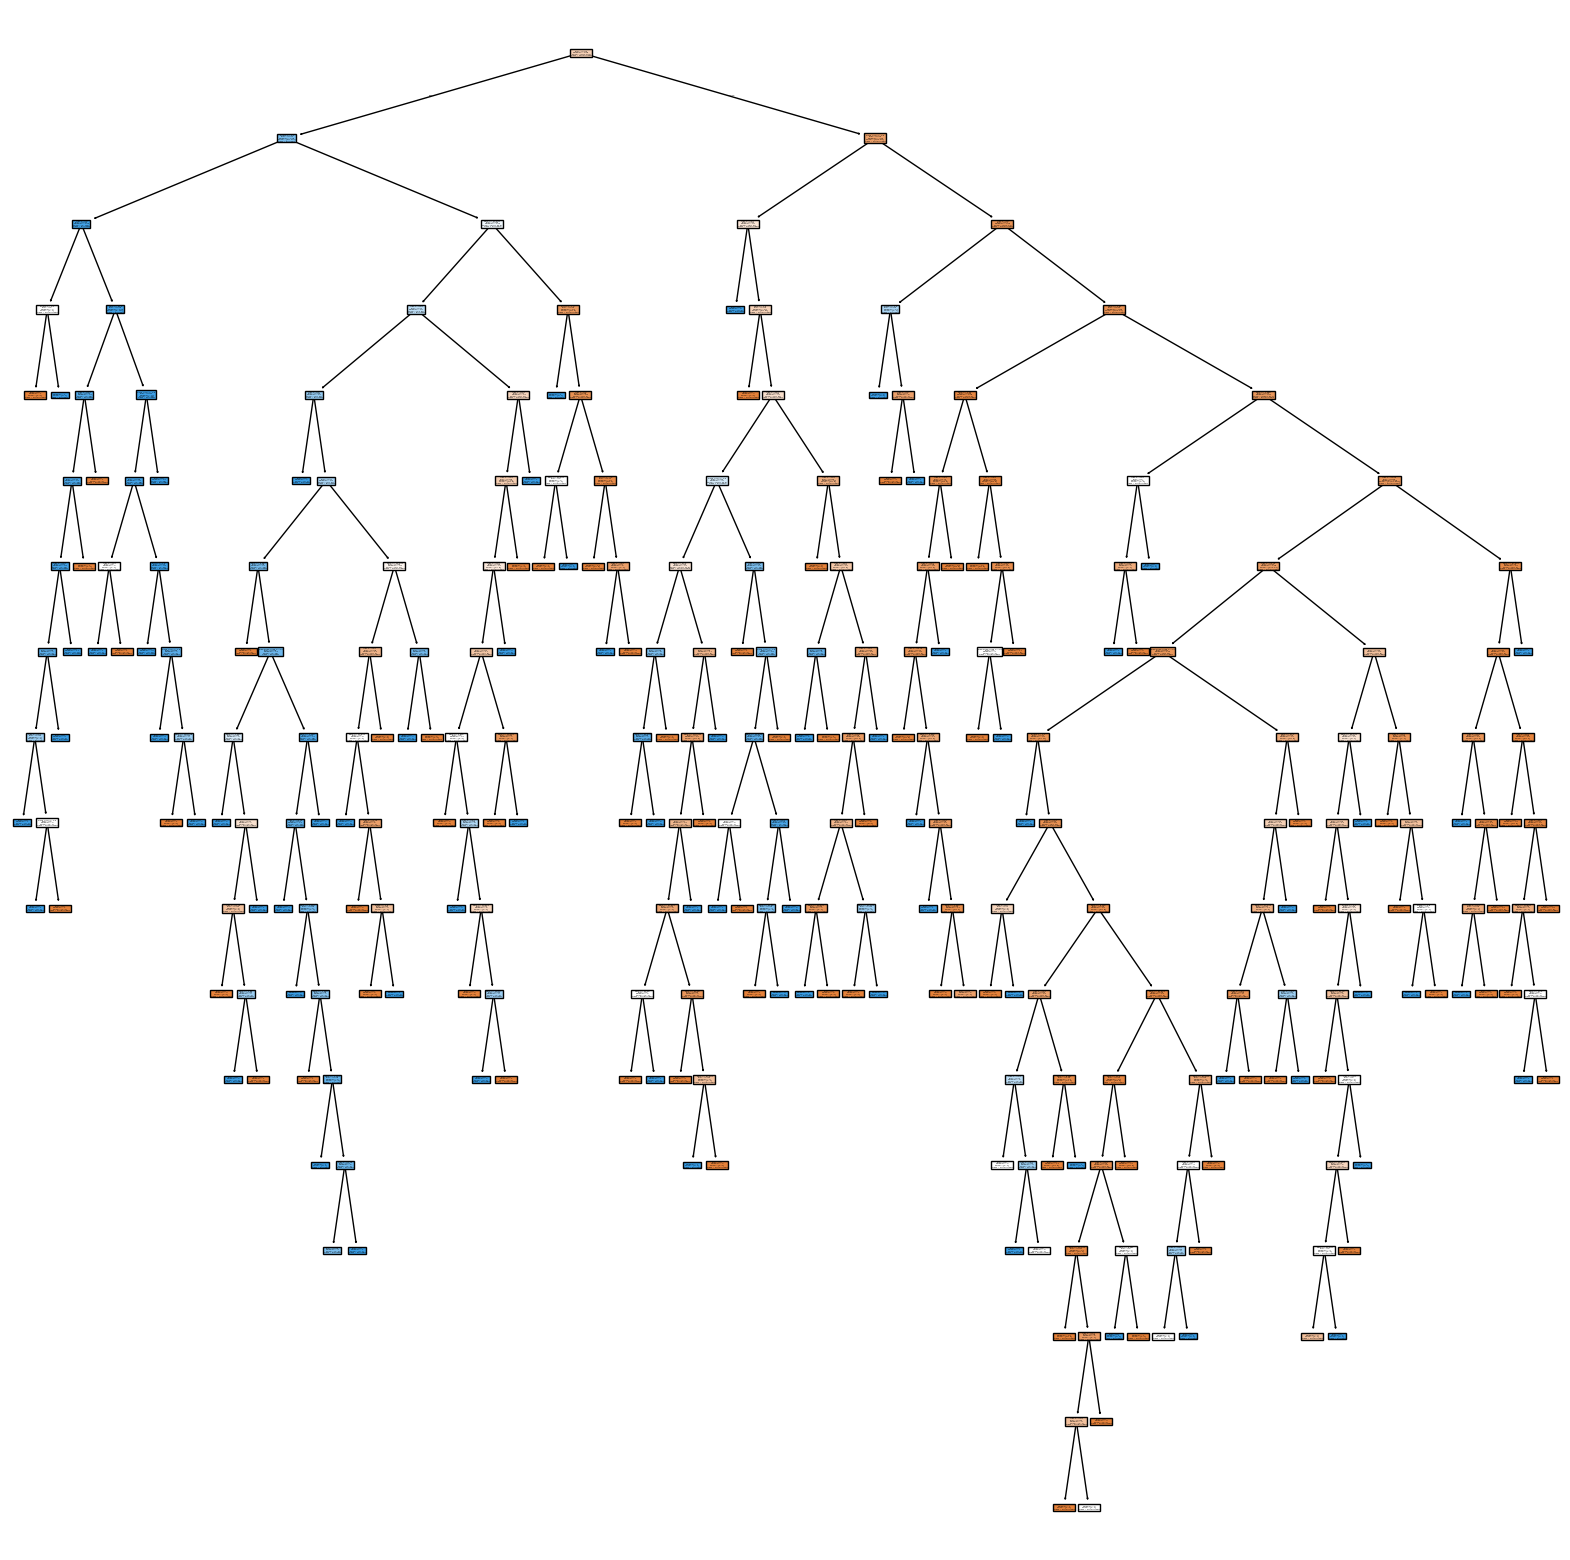

In [9]:
plt.figure(figsize=(20,20))
features = X.columns
classes = ['Not survived','Survived']
tree.plot_tree(model,feature_names=features,class_names=classes,filled=True)
plt.show()

# Performance evaluation of the unpruned tree


Now that the model has been trained, we can evaluate the performance on both training and test set. To compare the two result we can use confusion matrix.
## What is a confusion matrix?
A confusion matrix is a table that shows how well your classification model performed comparing the actual true labels with the predicted labels.
The result are interpreted with:
*   True Negatives (TN)
*   False Positives (FP)
*   False Negatives (FN)
*   True Positives (TP)

Actually the overall correctness can be calculated with this formula:

$$Accuracy=\frac{TP + TN}{TP + TN + FP + FN}$$

The helper function for confusion matrix is taken by https://www.kaggle.com/code/arunmohan003/pruning-decision-trees-tutorial.


In [10]:
# helper function
def plot_confusionmatrix(y_train_pred,y_train,dom):
    print(f'{dom} Confusion matrix')
    cf = confusion_matrix(y_train_pred,y_train)
    sns.heatmap(cf,annot=True,yticklabels=classes
               ,xticklabels=classes,cmap='Blues', fmt='g')
    plt.tight_layout()
    plt.show()
    print('\n')

The train accuracy score is very high approaching 100%, therefore our model is overfitting since the test accuracy score is not as high. Our model may fail to generalize on new unseen examples!

In [11]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print(f'Train score (accuracy): {accuracy_score(y_train_pred,y_train)}')
print(f'Test score (accuracy): {accuracy_score(y_test_pred,y_test)}')

Train score (accuracy): 0.9895209580838323
Test score (accuracy): 0.7488789237668162


Train Confusion matrix


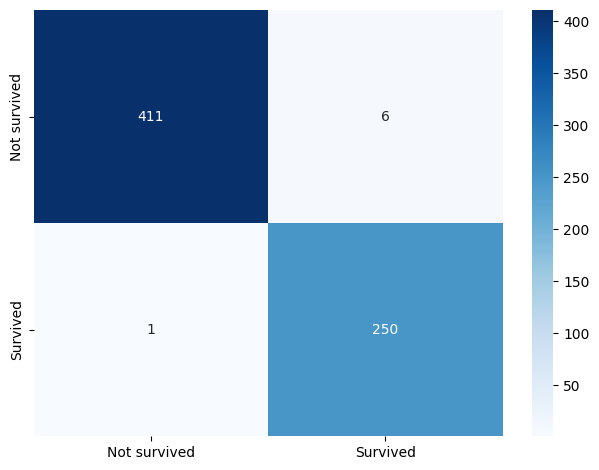



Test Confusion matrix


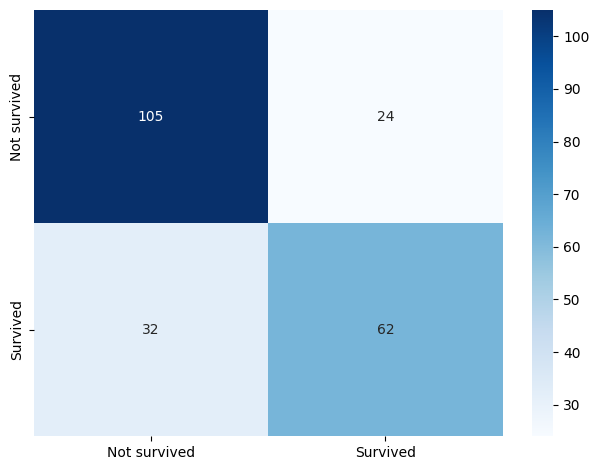

In [12]:
plot_confusionmatrix(y_train_pred,y_train,dom='Train')
plot_confusionmatrix(y_test_pred,y_test,dom='Test')

# Pre-pruning

Pre-pruning, also known as early stopping, involves halting the growth of the decision tree before it becomes fully developed. In this way we can avoid that the tree become too large and also too complex. Another important aspect is that the tree is restricted from learning the noise in the training data.

In the next implementation we try to find the best hyperparameters for which the performance are better. In particular we will deal with the following hyperparameter:
*   Maximum depth of the tree
*   Minimum samples needed to split an internal node
*   Minimum samples in a leaf node



In [13]:
params = {'max_depth': [2,4,6,8,10,12],
         'min_samples_split': [2,3,4],
         'min_samples_leaf': [1,2]}

prepruning_model = tree.DecisionTreeClassifier(random_state=0)
gcv = GridSearchCV(estimator=prepruning_model,param_grid=params)
gcv.fit(X_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 12],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3, 4]})

After selecting the best perfoming model given all the possible combinations between the parameters, we can evaluate the results on the pruned tree. Now our model doesn't fit the training data well as before but we can see an improvement in accuracy for the test set, so our model will generalize better on new unseen examples.

In [14]:
prepruning_model = gcv.best_estimator_ # best estimator among the 36 models evaluated
prepruning_model.fit(X_train,y_train)
y_train_pred = prepruning_model.predict(X_train)
y_test_pred = prepruning_model.predict(X_test)
print(f'Train score (accuracy): {accuracy_score(y_train_pred,y_train)}')
print(f'Test score (accuracy): {accuracy_score(y_test_pred,y_test)}')

Train score (accuracy): 0.8413173652694611
Test score (accuracy): 0.7982062780269058


Train Confusion matrix


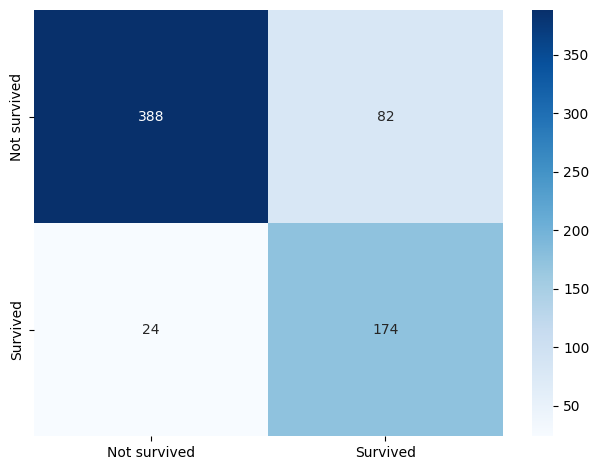



Test Confusion matrix


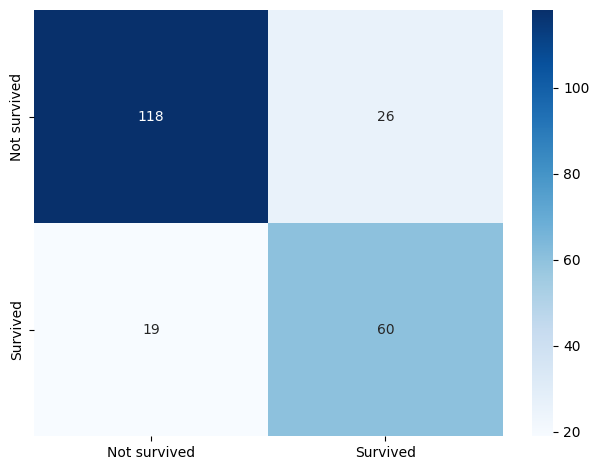

In [15]:
plot_confusionmatrix(y_train_pred,y_train,dom='Train')
plot_confusionmatrix(y_test_pred,y_test,dom='Test')

If you remember the size of the unpruned tree, you can notice that now our pruned tree is much shorter as expected.

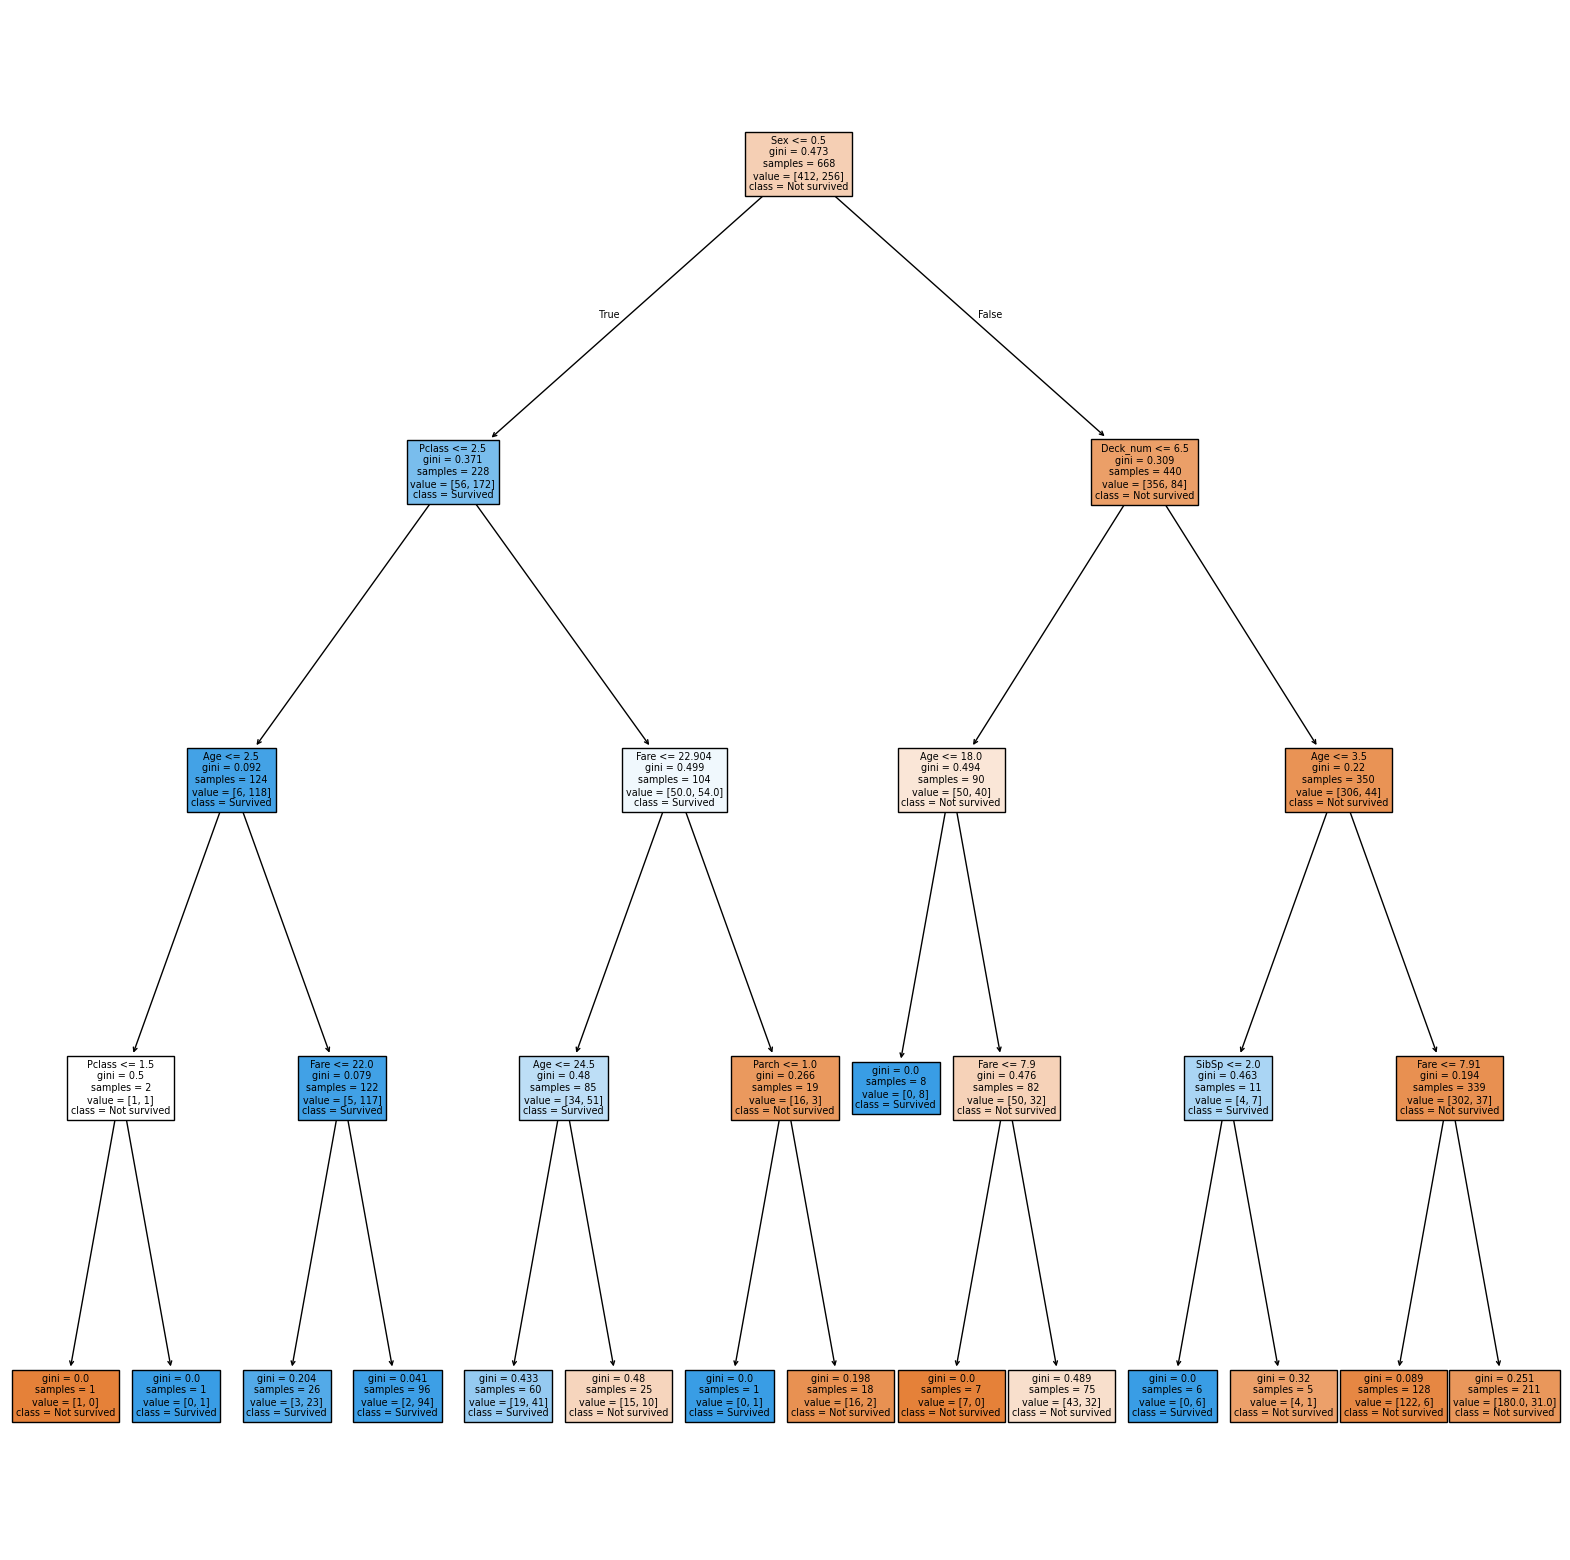

In [16]:
plt.figure(figsize=(20,20))
features = X.columns
classes = ['Not survived','Survived']
tree.plot_tree(prepruning_model,feature_names=features,class_names=classes,filled=True)
plt.show()

# Post-pruning

Now that we have exploit the idea of pre-pruning, we can also explore other post-pruning approaches. Post-pruning is the process of growing the decision tree fully, allowing it to overfit the training data, and then trimming back unnecessary branches that do not contribute to improving accuracy on unseen data. Some approaches that we saw in class during previous lectures like "Reduced Error Pruning" and "Rule Post Pruning" are a form of post-pruning.

In the next example, we will look at a different post-pruning technique implemented directly in scikit-learn. This approach is called "Cost Complexity Pruning".

## Cost Complexity Pruning
This pruning technique is parameterized by the cost complexity parameter ```ccp_alpha```. For greater values of ```ccp_alpha``` we can expect an increased number of nodes pruned. To understand how it performs the pruning we need to introduce the minimal cost-complexity pruning algorithm.

## Minimal Cost-Complexity Pruning
Reference: https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning

The complexity parameter $α \geq 0$ is used to define the cost-complexity measure $R_\alpha(T)$, of a given tree $T$.
$$R_\alpha(T)=R(T)+\alpha|\widetilde{T}|$$

where $|\widetilde{T}|$ is the number of terminal nodes in $T$ and $R(T)$ is the total sample weighted impurity of the terminal nodes for $R(T)$:

$$R(T)=\sum_{t \in \widetilde{T}} w_t \cdot I(t)$$

where $t$ is a terminal node, $w_t$ is the proportion of samples that reach that leaf and $I(t)$ is the impurity of that leaf (Gini, Cross-Entropy, etc.).
Minimal cost-complexity pruning finds the subtree of $T$ that minimizes $R_\alpha(T)$.

It is clear that the cost-complexity of a single node is $R_\alpha(t)=R(t)+\alpha$. We can call $T_t$ the subtree rooted on node $T$. It appears to be evident that $R(T_t)< R(t)$, because it is unlikely that the impurity of a node is smaller or equal to the weighted sum of impurity for its terminal nodes. However we can make $R_\alpha(T_t)= R_\alpha(t)$ because they are depending on $\alpha$, so we can define the effective $\alpha$ of a node to be the value where $R_\alpha(T_t)= R_\alpha(t)$. This is also equal to say:
$$\alpha_{e f f}(t)=\frac{R(t)-R\left(T_t\right)}{|T|-1}$$

A non-terminal node with the smallest value of $\alpha_{e f f}$ is the weakest link and will be pruned. This process stops when the pruned tree's minimal $\alpha_{e f f}$ is greater than the complexity parameter $\alpha$.

In other words we start with the fully grown tree and for each non-terminal node compute $\alpha_{e f f}(t)$, then find the smallest $\alpha_{e f f}(t)$ and prune the subtree rooted on node $t$. We need to repeat the process iteratively, each time pruning the weakest link and recording the corresponding $\alpha_{e f f}$. This process produce a sequence of trees associated with increasing $\alpha_{e f f}$ values.
Once the sequence of all $\alpha_{e f f}$ is created we can choose the best pruned tree for a fixed $\alpha$ in which $\alpha_{e f f}\leq \alpha$.



In [17]:
# To begin we can use the initial model we fitted before without any pruning
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print(ccp_alphas)

[0.00000000e+00 1.24750499e-04 2.99401198e-04 3.26619488e-04
 4.53638178e-04 4.99001996e-04 7.17315369e-04 7.23552894e-04
 7.33826465e-04 7.98403194e-04 8.73253493e-04 8.98203593e-04
 9.71740729e-04 9.76834210e-04 9.82683755e-04 9.98003992e-04
 1.16433799e-03 1.19760479e-03 1.24967456e-03 1.26413839e-03
 1.28314799e-03 1.33067199e-03 1.39007699e-03 1.42915087e-03
 1.49700599e-03 1.49700599e-03 1.60001966e-03 1.66333999e-03
 1.71632541e-03 1.79640719e-03 1.81779299e-03 1.86234674e-03
 1.87125749e-03 1.92472198e-03 1.94610778e-03 1.96974472e-03
 1.99600798e-03 2.01264138e-03 2.06939063e-03 2.11342022e-03
 2.21001724e-03 2.21068161e-03 2.22438089e-03 2.24113177e-03
 2.24550898e-03 2.24550898e-03 2.30505352e-03 2.38743799e-03
 2.39520958e-03 2.49500998e-03 3.07955518e-03 3.19117862e-03
 3.56251782e-03 3.93176495e-03 4.18710642e-03 4.24151697e-03
 5.22591181e-03 8.11385359e-03 8.86666157e-03 9.08749303e-03
 2.17749782e-02 3.16598747e-02 1.42763369e-01]


```ccp_alphas``` represents a list of possible alpha values that correspond to different pruning stages of the tree. For example ```ccp_alphas=0``` is when the tree is free to grow fully. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves because we are losing some details.



In [18]:
models = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    models.append(clf)

# We can remove the last classifier that should be the tree with only the root node
models = models[:-1]
ccp_alphas = ccp_alphas[:-1]

In the next charts we can see that as alpha tend to grows, the number of nodes tend to decrease as expected, and this is also true for the depth of the tree.

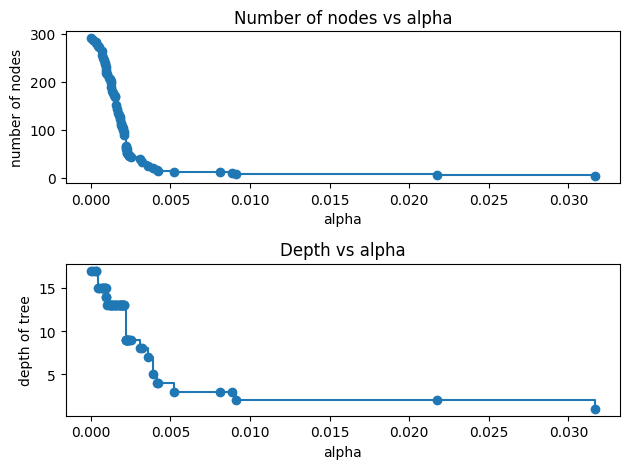

In [19]:
node_counts = [clf.tree_.node_count for clf in models]
depth = [clf.tree_.max_depth for clf in models]
plt.subplot(2, 1, 1)
plt.plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
plt.xlabel("alpha")
plt.ylabel("number of nodes")
plt.title("Number of nodes vs alpha")
plt.subplot(2, 1, 2)
plt.plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
plt.xlabel("alpha")
plt.ylabel("depth of tree")
plt.title("Depth vs alpha")
plt.tight_layout()

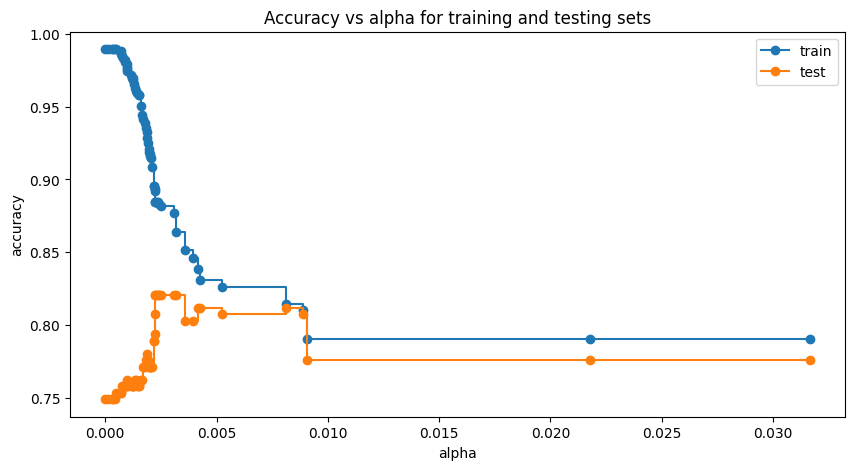

In [20]:
train_scores = [clf.score(X_train, y_train) for clf in models] # compute accuracy
test_scores = [clf.score(X_test, y_test) for clf in models]

fig = plt.figure(figsize=(10,5))
plt.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
plt.xlabel("alpha")
plt.ylabel("accuracy")
plt.title("Accuracy vs alpha for training and testing sets")
plt.legend()
plt.show()

Here we take the alpha that maximize the accuracy on the testing set, and graphically it appears to be ```cp_alpha=0.0025```.

In [21]:
postpruning_model = tree.DecisionTreeClassifier(random_state=0,ccp_alpha=0.0025)
postpruning_model.fit(X_train,y_train)
y_train_pred = postpruning_model.predict(X_train)
y_test_pred = postpruning_model.predict(X_test)

print(f'Train score (accuracy): {accuracy_score(y_train_pred,y_train)}')
print(f'Test score (accuracy): {accuracy_score(y_test_pred,y_test)}')

Train score (accuracy): 0.8817365269461078
Test score (accuracy): 0.820627802690583


Again we've improved the accuracy on the testing set, showing a result that is also better than the pre-pruning approach.

In [22]:
# We can also compute the exact best alpha (in this case use the alpha estimated graphically is the same as using best_alpha)
index = np.argmax(test_scores)
best_alpha = ccp_alphas[index]
print(best_alpha)

0.002245508982035928


Train Confusion matrix


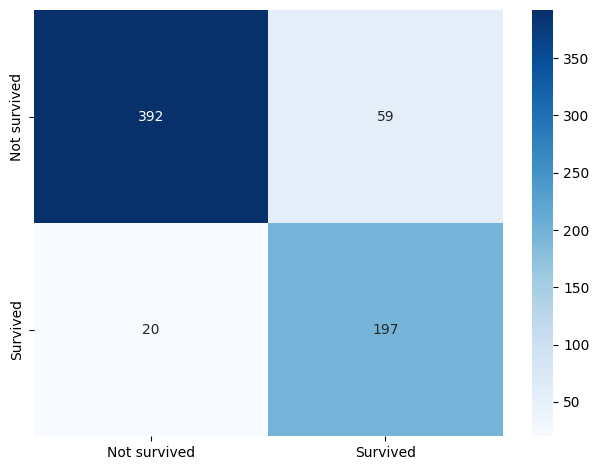



Test Confusion matrix


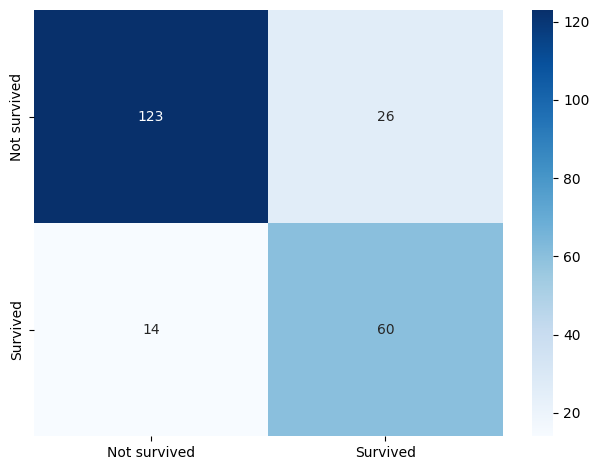

In [23]:
plot_confusionmatrix(y_train_pred,y_train,dom='Train')
plot_confusionmatrix(y_test_pred,y_test,dom='Test')

The pruned tree is much shorter than the initial unpruned one as expected, and it is also more understandable.

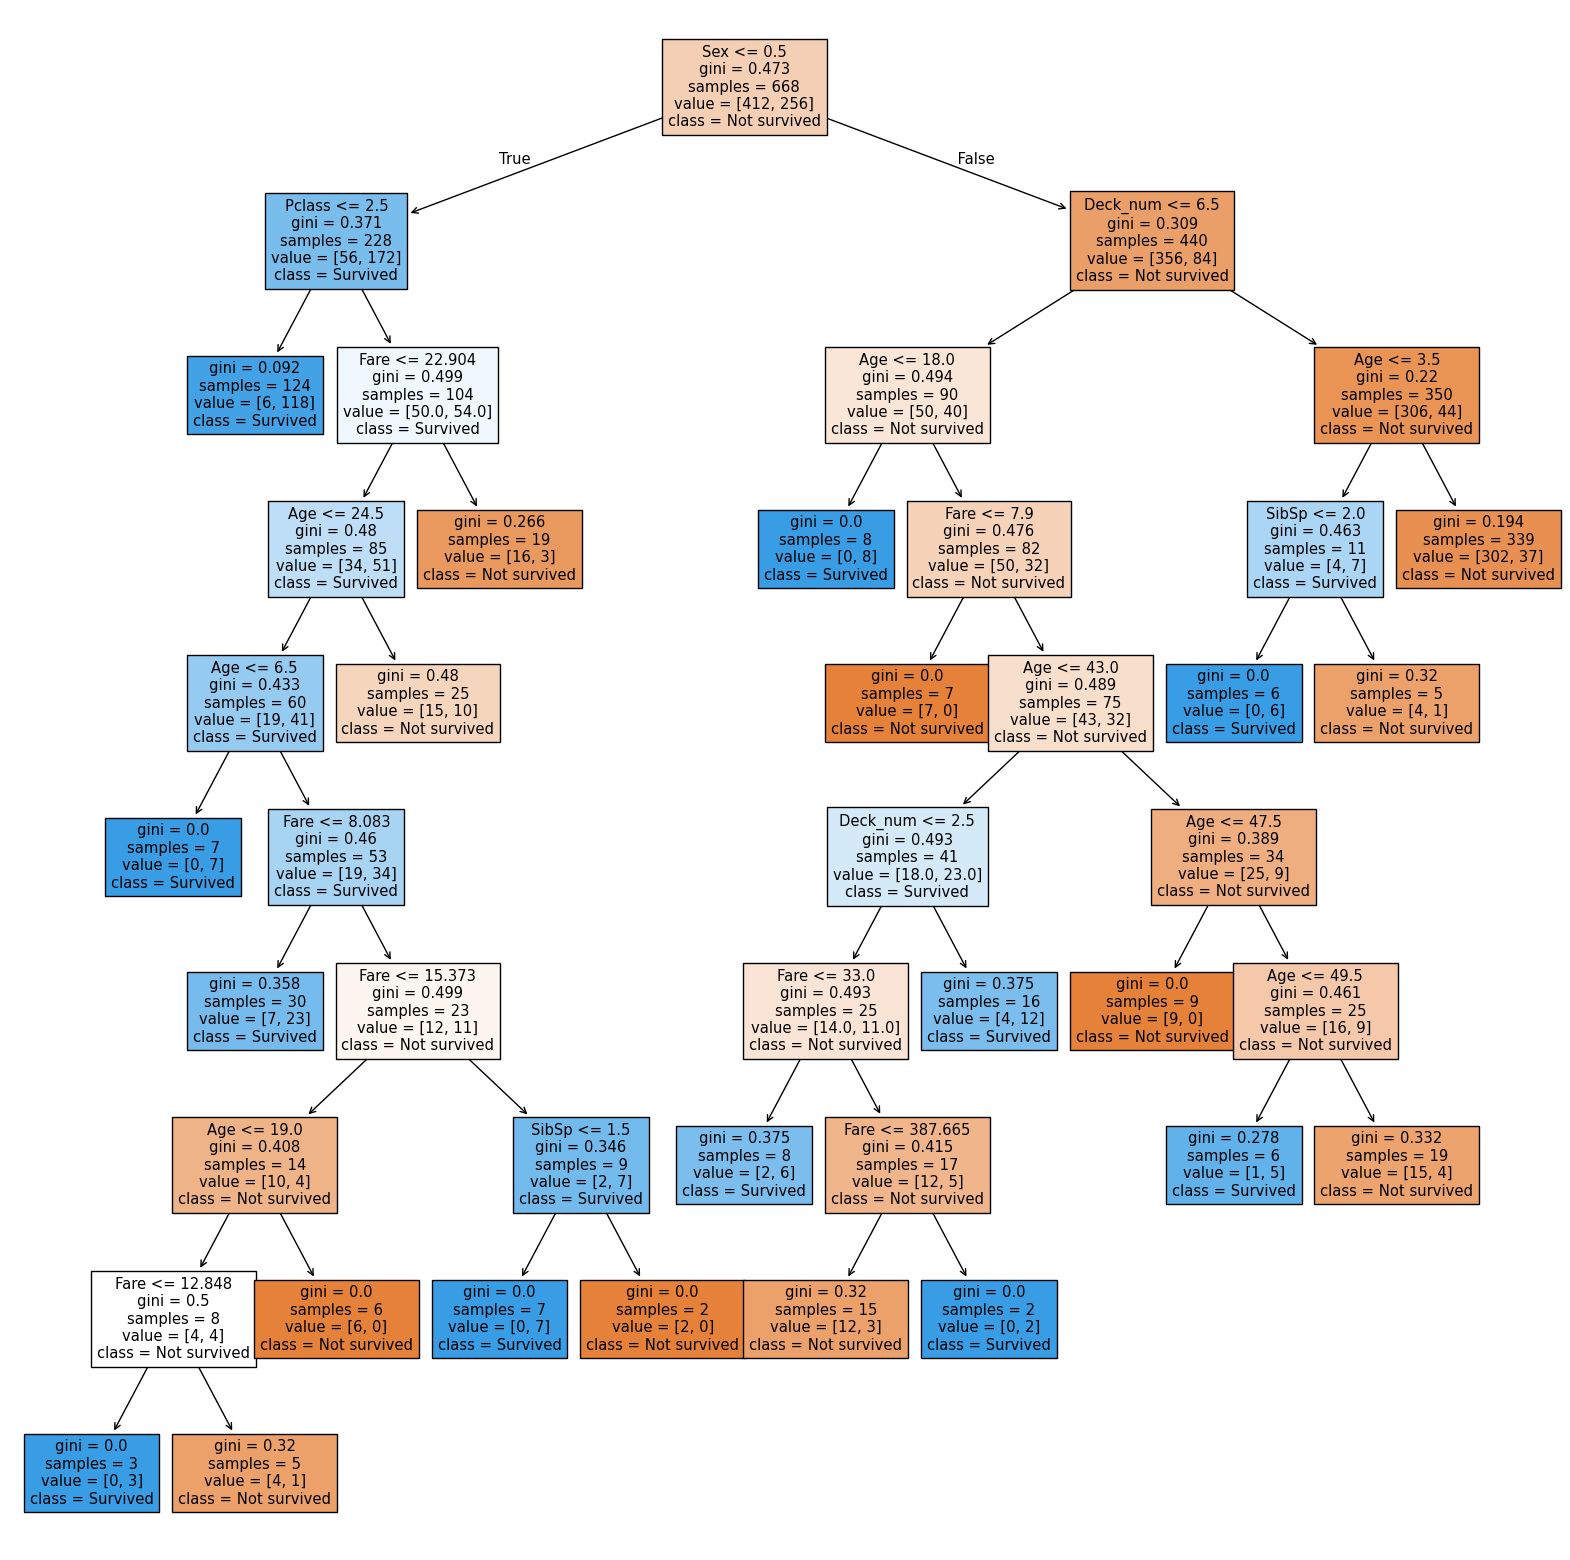

In [24]:
plt.figure(figsize=(20,20))
features = X.columns
classes = ['Not survived','Survived']
tree.plot_tree(postpruning_model,feature_names=features,class_names=classes,filled=True)
plt.show()

# Conclusion

In this notebook we showed how pruning can lead to better performace on new unseen examples, helping to avoid the problem of overfitting. We implemented two different approaches of pruning, and this experiment shows the effectiveness of pruning. In particular post-pruning led to achieve better accuracy score for the testing set. This is because since the tree is first grown fully and then pruned, post-pruning allows the model to consider all possible patterns before discarding irrelevant or weak patterns. Meanwhile pre-pruned tree may risk underfitting if the stopping criteria are too strict.

# References

Lesson 06 - Decision Tree (Part 2) (slides)

https://www.kaggle.com/datasets/yasserh/titanic-dataset

https://www.kaggle.com/code/arunmohan003/pruning-decision-trees-tutorial

https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning

https://medium.com/@abhishekjainindore24/pre-pruning-and-post-pruning-in-decision-trees-a-comprehensive-guide-391fd3682883